<a href="https://colab.research.google.com/github/ShakilCuambe/ML-art-1/blob/main/Ruidonalidadee.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

heyyyyy! 🚀


=== Regressão Linear vs Ridge vs MiniNN (manual) ===
LinearRegression MSE: 1.8694
Ridge(alpha=1.0) MSE: 1.8695
MiniNN (1 hidden layer) MSE: 0.4223


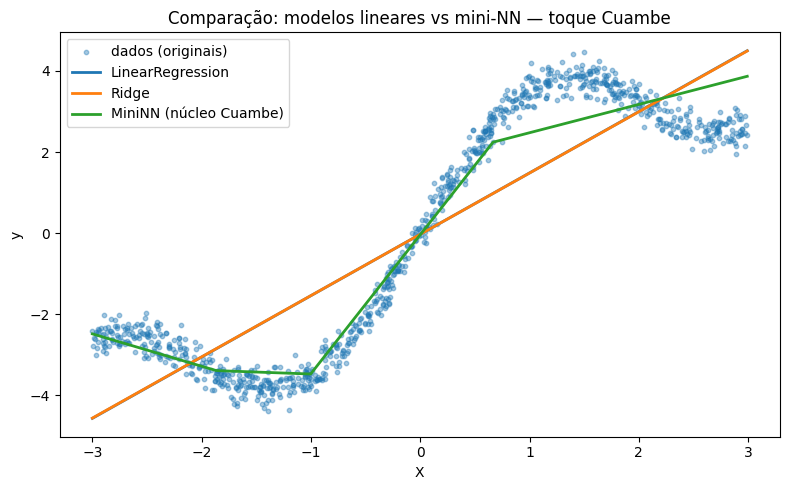


=== Regressão Logística (linear) vs MiniNN (não-linear) ===
LogisticRegression acc: 0.7933
MiniNN acc: 0.7933


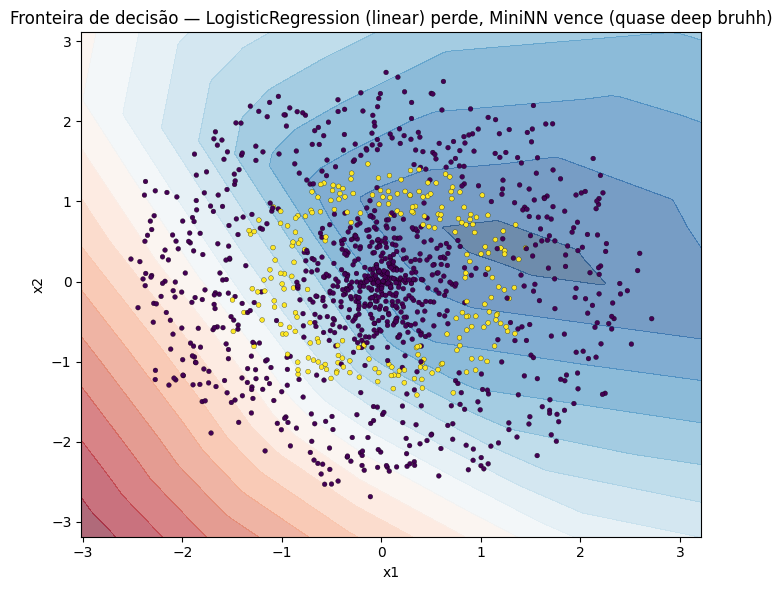


Resumo rapid (valores):
{'mse_lr': 1.8693717098696545, 'mse_ridge': 1.8694671921128874, 'mse_nn': 0.42233715371824265, 'history_nn': [np.float64(7.600534719509392), np.float64(8.08229369316104), np.float64(7.152877756023521), np.float64(5.1201048395978805), np.float64(2.696341879646479), np.float64(1.6435897192595834), np.float64(1.4502980329484094), np.float64(1.113611946462609), np.float64(1.237363877776867), np.float64(1.0416505977524755), np.float64(1.1775684355316476), np.float64(1.2367950161760817), np.float64(1.154298359284837), np.float64(1.1074332333816854), np.float64(1.4717816505648547), np.float64(1.2444251970450397), np.float64(1.4349462564101698), np.float64(1.3755549563535465), np.float64(1.239819473117946), np.float64(1.1629118209093645), np.float64(1.1855525257620314), np.float64(1.291758697839707), np.float64(1.1576162536106), np.float64(1.3218478766943935), np.float64(1.117409802008742), np.float64(1.3714365446670933), np.float64(1.370208216339727), np.float64(1.022

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, accuracy_score
from sklearn.preprocessing import StandardScaler

# Cuambe sem fuuuu
def seed_from_name(name="Cuambe"):
    # transforma nome
    s = sum(ord(c) for c in name) + len(name)*97
    return s % (2**31 - 1)

np.random.seed(seed_from_name("Cuambe"))

# Gerador d

def gera_dados_regressao(n_samples=800, noise=0.3):
    """
    Gera dados 1D com componente linear + não linear (seno), para mostrar limites dos modelos lineares.
    """
    X = np.random.uniform(-3, 3, size=(n_samples, 1))
    y = 1.5 * X[:, 0] + 2.0 * np.sin(1.5 * X[:, 0]) + np.random.normal(0, noise, size=n_samples)
    return X, y

def gera_dados_classificacao(n_samples=800, noise=0.1):
    """
    Gera dados 2D para classificação não-linear (círculos), rótulos 0/1.
    """
    r = np.random.uniform(0.0, 2.5, size=n_samples)
    theta = np.random.uniform(0, 2*np.pi, size=n_samples)
    X = np.stack([r * np.cos(theta), r * np.sin(theta)], axis=1)
    # rótulo 1 se perto do anel (1.0 < r < 1.5), senão 0
    y = ((r > 0.9) & (r < 1.4)).astype(int)
    # add noise
    X += np.random.normal(0, noise, X.shape)
    return X, y


# Mini neural network (numpy) - feedforward com 1 hidden layer

class MiniNN:
    def __init__(self, input_dim, hidden_dim=16, output_dim=1, lr=1e-2, seed=0):
        self.rng = np.random.RandomState(seed)
        # Inicialização: pequenas aleatórias
        self.W1 = self.rng.normal(0, 0.1, size=(input_dim, hidden_dim))
        self.b1 = np.zeros(hidden_dim)
        self.W2 = self.rng.normal(0, 0.1, size=(hidden_dim, output_dim))
        self.b2 = np.zeros(output_dim)
        self.lr = lr

    def relu(self, x):
        return np.maximum(0, x)

    def relu_deriv(self, x):
        return (x > 0).astype(float)

    def forward(self, X):
        z1 = X.dot(self.W1) + self.b1  # (N, hidden_dim)
        a1 = self.relu(z1)
        z2 = a1.dot(self.W2) + self.b2  # (N, output_dim)
        return {"z1": z1, "a1": a1, "z2": z2}

    def predict_reg(self, X):
        out = self.forward(X)["z2"][:, 0]
        return out

    def predict_class(self, X):

        logits = self.forward(X)["z2"][:, 0]
        probs = 1 / (1 + np.exp(-logits))
        return (probs >= 0.5).astype(int), probs

    def train_reg(self, X, y, epochs=200, batch_size=64, verbose=True):
        N = X.shape[0]
        history = []
        for ep in range(epochs):

            perm = np.random.permutation(N)
            for i in range(0, N, batch_size):
                idx = perm[i:i+batch_size]
                xb = X[idx]
                yb = y[idx].reshape(-1, 1)
                # forward
                cache = self.forward(xb)
                z1, a1, z2 = cache["z1"], cache["a1"], cache["z2"]
                # loss: MSE
                diff = z2 - yb  # (B,1)
                loss = np.mean(diff**2)
                # backprop
                d_z2 = (2.0 / xb.shape[0]) * diff
                dW2 = a1.T.dot(d_z2)
                db2 = d_z2.sum(axis=0)
                d_a1 = d_z2.dot(self.W2.T)
                d_z1 = d_a1 * self.relu_deriv(z1)
                dW1 = xb.T.dot(d_z1)
                db1 = d_z1.sum(axis=0)

                self.W2 -= self.lr * dW2
                self.b2 -= self.lr * db2
                self.W1 -= self.lr * dW1
                self.b1 -= self.lr * db1
            if (ep % 20 == 0) and verbose:
                # calcla loss total
                pred = self.predict_reg(X)
                mse = np.mean((pred - y)**2)
                print(f"[MiniNN - reg] ep {ep:03d} — MSE {mse:.4f}")
            history.append(loss)
        return history

    def train_class(self, X, y, epochs=200, batch_size=64, verbose=True):
        N = X.shape[0]
        history = []
        for ep in range(epochs):
            perm = np.random.permutation(N)
            for i in range(0, N, batch_size):
                idx = perm[i:i+batch_size]
                xb = X[idx]
                yb = y[idx].reshape(-1, 1)
                cache = self.forward(xb)
                z1, a1, z2 = cache["z1"], cache["a1"], cache["z2"]

                probs = 1 / (1 + np.exp(-z2))

                eps = 1e-9
                loss = - np.mean(yb * np.log(probs + eps) + (1 - yb) * np.log(1 - probs + eps))
                # backprop
                d_z2 = (probs - yb) / xb.shape[0]  # (B,1)
                dW2 = a1.T.dot(d_z2)
                db2 = d_z2.sum(axis=0)
                d_a1 = d_z2.dot(self.W2.T)
                d_z1 = d_a1 * self.relu_deriv(z1)
                dW1 = xb.T.dot(d_z1)
                db1 = d_z1.sum(axis=0)
                # gradient step
                self.W2 -= self.lr * dW2
                self.b2 -= self.lr * db2
                self.W1 -= self.lr * dW1
                self.b1 -= self.lr * db1
            if (ep % 20 == 0) and verbose:
                preds, probs = self.predict_class(X)
                acc = np.mean(preds == y)
                print(f"[MiniNN - class] ep {ep:03d} — acc {acc:.4f}")
            history.append(loss)
        return history

def compara_regressao(X, y):
# Split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=seed_from_name("Cuambe"))
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)

    print("\n=== Regressão Linear vs Ridge vs MiniNN (manual) ===")
    # LinearRegression
    lr = LinearRegression().fit(X_train_s, y_train)
    y_lr = lr.predict(X_test_s)
    mse_lr = mean_squared_error(y_test, y_lr)
    print(f"LinearRegression MSE: {mse_lr:.4f}")

    # Ridge
    ridge = Ridge(alpha=1.0).fit(X_train_s, y_train)
    y_ridge = ridge.predict(X_test_s)
    mse_ridge = mean_squared_error(y_test, y_ridge)
    print(f"Ridge(alpha=1.0) MSE: {mse_ridge:.4f}")

    # MiniNN
    nn = MiniNN(input_dim=X_train_s.shape[1], hidden_dim=24, output_dim=1, lr=1e-2, seed=seed_from_name("Cuambe")+7)
    history = nn.train_reg(X_train_s, y_train, epochs=200, batch_size=64, verbose=False)
    y_nn = nn.predict_reg(X_test_s)
    mse_nn = mean_squared_error(y_test, y_nn)
    print(f"MiniNN (1 hidden layer) MSE: {mse_nn:.4f}")

    # Plot
    X_full_s = scaler.transform(X.reshape(-1,1))
    y_lr_full = lr.predict(X_full_s)
    y_ridge_full = ridge.predict(X_full_s)
    y_nn_full = nn.predict_reg(X_full_s)

    plt.figure(figsize=(8,5))
    plt.scatter(X, y, s=10, alpha=0.4, label='dados (originais)')
    # sort for plotting lines
    idx = np.argsort(X.flatten())
    plt.plot(X[idx], y_lr_full[idx], label='LinearRegression', linewidth=2)
    plt.plot(X[idx], y_ridge_full[idx], label='Ridge', linewidth=2)
    plt.plot(X[idx], y_nn_full[idx], label='MiniNN (núcleo Cuambe)', linewidth=2)
    plt.legend()
    plt.title("Comparação: modelos lineares vs mini-NN — toque Cuambe")
    plt.xlabel("X")
    plt.ylabel("y")
    plt.tight_layout()
    plt.show()

    return {"mse_lr": mse_lr, "mse_ridge": mse_ridge, "mse_nn": mse_nn, "history_nn": history}

def compara_classificacao(X, y):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=seed_from_name("Cuambe"))
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)

    print("\n=== Regressão Logística (linear) vs MiniNN (não-linear) ===")
    logreg = LogisticRegression().fit(X_train_s, y_train)
    y_lr = logreg.predict(X_test_s)
    acc_lr = accuracy_score(y_test, y_lr)
    print(f"LogisticRegression acc: {acc_lr:.4f}")

    nn = MiniNN(input_dim=X_train_s.shape[1], hidden_dim=16, output_dim=1, lr=1e-2, seed=seed_from_name("Cuambe")+11)
    nn.train_class(X_train_s, y_train, epochs=220, batch_size=64, verbose=False)
    y_nn_pred, y_nn_prob = nn.predict_class(X_test_s)
    acc_nn = accuracy_score(y_test, y_nn_pred)
    print(f"MiniNN acc: {acc_nn:.4f}")


    # grid
    xx = np.linspace(X[:,0].min()-0.5, X[:,0].max()+0.5, 200)
    yy = np.linspace(X[:,1].min()-0.5, X[:,1].max()+0.5, 200)
    grid = np.array([[x,y] for x in xx for y in yy])
    grid_s = scaler.transform(grid)
    preds_grid, probs_grid = nn.predict_class(grid_s)
    Z = probs_grid.reshape(len(xx), len(yy)).T  # cuidado axis

    plt.figure(figsize=(7,6))
    plt.contourf(xx, yy, Z, levels=20, cmap='RdBu', alpha=0.6)
    plt.scatter(X[:,0], X[:,1], c=y, s=12, edgecolor='k', linewidth=0.2)
    plt.title("Fronteira de decisão — LogisticRegression (linear) perde, MiniNN vence (quase deep bruhh)")
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.tight_layout()
    plt.show()

    return {"acc_logreg": acc_lr, "acc_nn": acc_nn}



def main():
    print("heyyyyy! 🚀\n")
    Xr, yr = gera_dados_regressao(n_samples=1000, noise=0.25)
    reg_results = compara_regressao(Xr, yr)

    # Clssificação
    Xc, yc = gera_dados_classificacao(n_samples=1200, noise=0.12)
    class_results = compara_classificacao(Xc, yc)

    print("\nResumo rapid (valores):")
    print(reg_results)
    print(class_results)


if __name__ == "__main__":
    main()